# Inspeção de Qualidade

## 1. Conhecendo o Dataset

### Classes
- def_front: peças defeituosas
- ok_front: peças em perfeito estado

### Formato das imagens
- .jpeg

### Observações visuais
- As peças defeituosas apresentam partes tortas, buracos e riscos.
- As peças da classe ok_front não apresentam essas irregularidades visíveis.
  
- Amostras selecionadas:

Imagem cast_ak_0_9658.jpeg:
Classe: ok_front
Motivo: peça em perfeito estado utilizada como referência.

Imagem cast_def_0_122.jpeg:
Classe: def_front
Motivo: apresenta defeito claramente visível.

Imagem cast_def_0_9643.jpeh:
Classe: def_front
Motivo: apresenta defeito mais discreto.



## 2. Análise Exploratória com OpenCV

### 3.1 Importação das bibliotecas

Nesta etapa são importadas as bibliotecas necessárias para carregar,
processar e visualizar as imagens utilizadas na análise exploratória.

In [2]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path


In [5]:
pasta_atual = Path.cwd()

if (pasta_atual / "dataset").exists():
    raiz_projeto = pasta_atual
elif (pasta_atual.parent / "dataset").exists():
    raiz_projeto = pasta_atual.parent
else:
    raise FileNotFoundError("Não foi possível localizar a pasta dataset.")

print("Raiz do projeto:", raiz_projeto)

Raiz do projeto: c:\Users\migue\OneDrive\Documentos\CURSO-SCTEC\projeto_inspecao_qualidade


In [6]:
caminho_imagem = (
    raiz_projeto
    / "dataset"
    / "casting_512x512"
    / "def_front"
    / "cast_def_0_122.jpeg"
)

print(caminho_imagem)

c:\Users\migue\OneDrive\Documentos\CURSO-SCTEC\projeto_inspecao_qualidade\dataset\casting_512x512\def_front\cast_def_0_122.jpeg


In [7]:
print("Arquivo encontrado:", caminho_imagem.exists())

Arquivo encontrado: True


In [8]:
imagem_bgr = cv2.imread(str(caminho_imagem))

In [9]:
if imagem_bgr is None:
    raise ValueError("A imagem não pôde ser carregada.")

print("Imagem carregada com sucesso.")

Imagem carregada com sucesso.


In [10]:
print("Formato da imagem:", imagem_bgr.shape)

Formato da imagem: (512, 512, 3)


In [11]:
imagem_rgb = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)

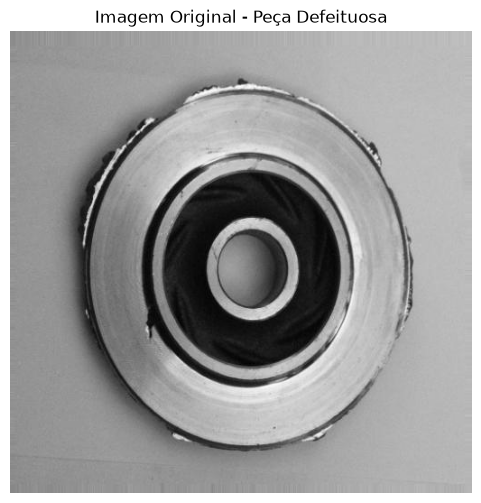

In [12]:
plt.figure(figsize=(6, 6))

plt.imshow(imagem_rgb)

plt.title("Imagem Original - Peça Defeituosa")

plt.axis("off")

plt.show()

### 3.2 Imagem Original

Inicialmente, a imagem defeituosa é carregada sem alterações para servir
como referência durante o processamento. Dessa forma, será possível
comparar a imagem original com os resultados obtidos nas etapas seguintes.

In [13]:
imagem_gray = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2GRAY)

In [14]:
print("Formato original:", imagem_bgr.shape)
print("Formato grayscale:", imagem_gray.shape)

Formato original: (512, 512, 3)
Formato grayscale: (512, 512)


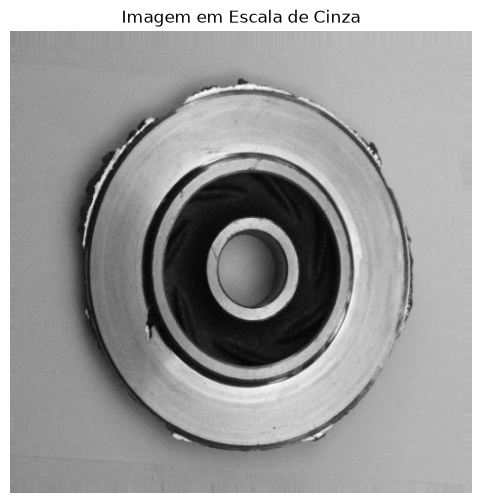

In [15]:
plt.figure(figsize=(6, 6))

plt.imshow(imagem_gray, cmap="gray")

plt.title("Imagem em Escala de Cinza")

plt.axis("off")

plt.show()

### 3.3 Conversão para Grayscale

A imagem foi convertida para escala de cinza com o objetivo de reduzir
a complexidade da informação visual. Nesta representação, o processamento
passa a considerar principalmente as diferenças de intensidade entre os
pixels, facilitando etapas posteriores como limiarização e detecção de bordas.

In [16]:
imagem_blur = cv2.GaussianBlur(
    imagem_gray,
    (5, 5),
    0
)

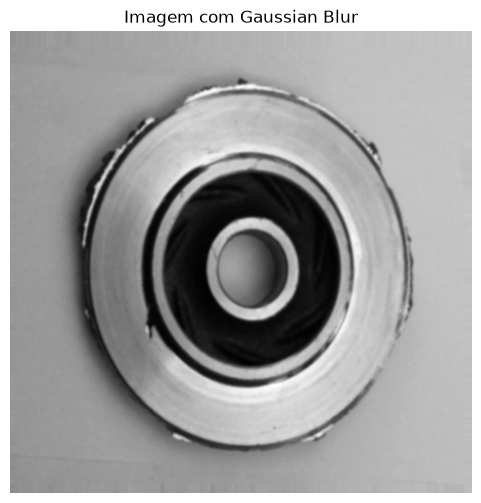

In [17]:
plt.figure(figsize=(6, 6))

plt.imshow(imagem_blur, cmap="gray")

plt.title("Imagem com Gaussian Blur")

plt.axis("off")

plt.show()

### 3.4 Suavização com Gaussian Blur

Após a conversão para escala de cinza, foi aplicado o Gaussian Blur
para reduzir pequenas variações e ruídos presentes na superfície da imagem.

A suavização é importante porque ruídos podem ser interpretados
incorretamente como bordas nas etapas seguintes. O objetivo é reduzir
esses detalhes sem eliminar as características associadas aos defeitos.

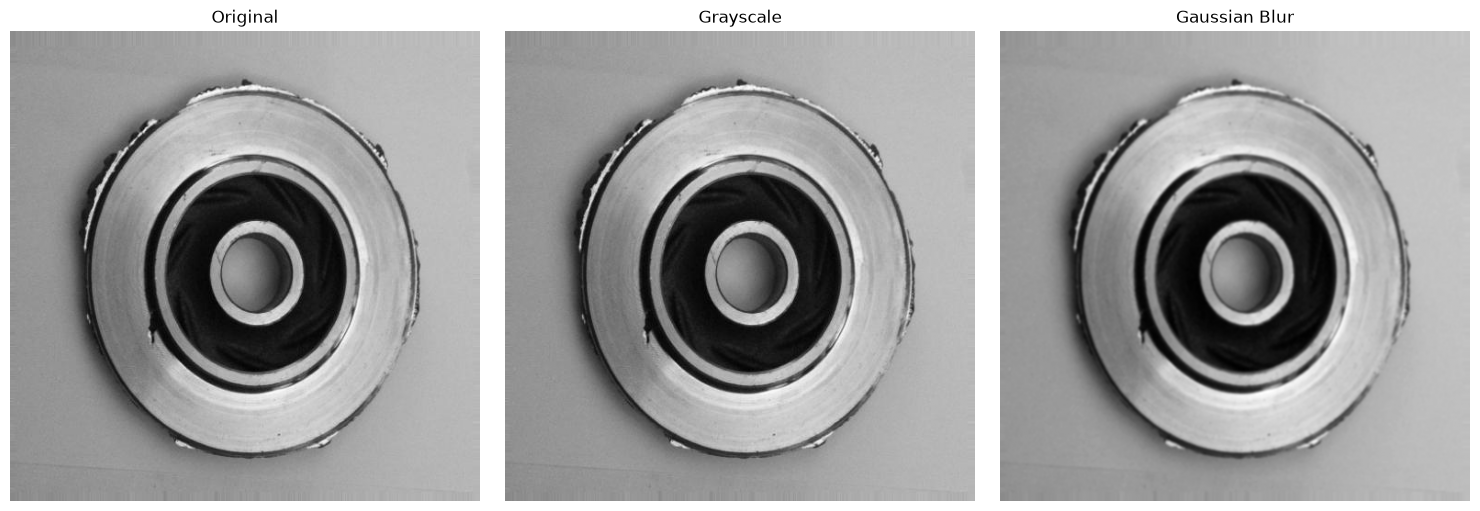

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(imagem_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(imagem_gray, cmap="gray")
axes[1].set_title("Grayscale")
axes[1].axis("off")

axes[2].imshow(imagem_blur, cmap="gray")
axes[2].set_title("Gaussian Blur")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Observação do resultado

Após a conversão para escala de cinza, os detalhes de intensidade da
superfície permaneceram visíveis. Com a aplicação do Gaussian Blur,
pequenas variações da textura foram suavizadas, enquanto o defeito
principal da peça continuou perceptível.

In [19]:
blur_3 = cv2.GaussianBlur(imagem_gray, (3, 3), 0)
blur_5 = cv2.GaussianBlur(imagem_gray, (5, 5), 0)
blur_7 = cv2.GaussianBlur(imagem_gray, (7, 7), 0)

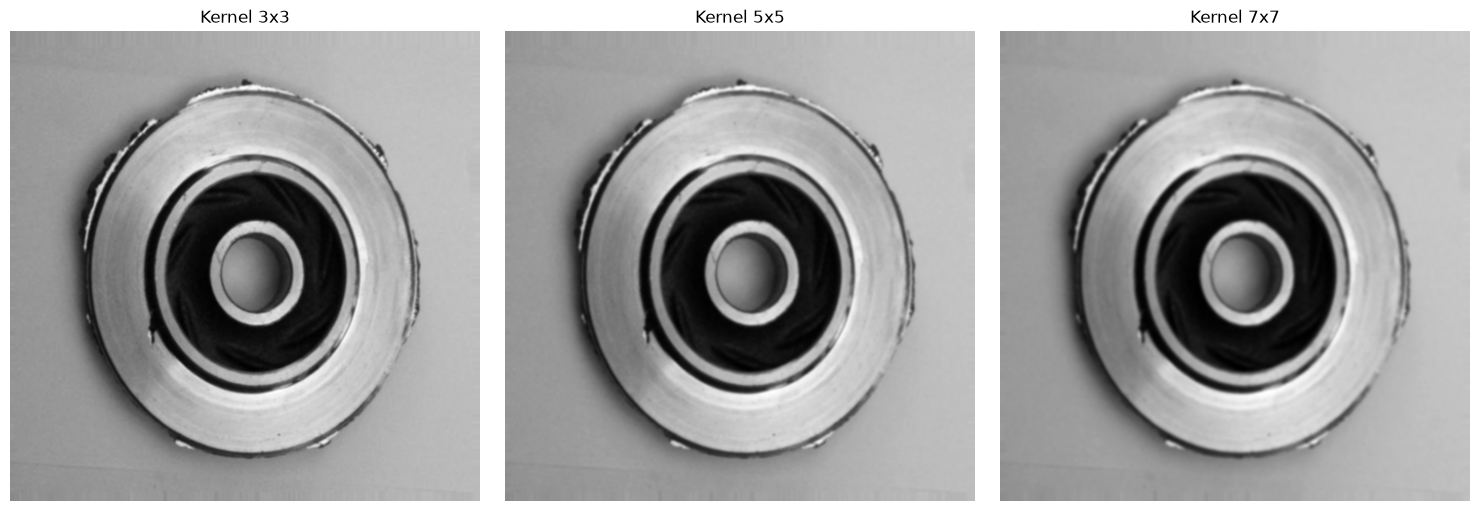

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(blur_3, cmap="gray")
axes[0].set_title("Kernel 3x3")
axes[0].axis("off")

axes[1].imshow(blur_5, cmap="gray")
axes[1].set_title("Kernel 5x5")
axes[1].axis("off")

axes[2].imshow(blur_7, cmap="gray")
axes[2].set_title("Kernel 7x7")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [21]:
pasta_resultados = raiz_projeto / "resultados"

pasta_resultados.mkdir(exist_ok=True)

In [22]:
cv2.imwrite(
    str(pasta_resultados / "defeito_grayscale.jpeg"),
    imagem_gray
)

cv2.imwrite(
    str(pasta_resultados / "defeito_gaussian_blur.jpeg"),
    imagem_blur
)

True